In [1]:
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import xml.etree.ElementTree as ET
from PIL import Image
import torch.optim as optim
import torch
import os

RuntimeError: operator torchvision::nms does not exist

In [ ]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

Part 0: NN Foundations







1.    
Implement a simple 2-layer neural network from scratch
using nn.Module — no nn.Sequential shortcuts. Define __init__ and forward
explicitly.

In [ ]:
class TwoLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNet, self).__init__()

        # Defining the layers
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self,x):
        #Forward Pass
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

# Example usage
if __name__ == "__main__":
    #Hyperparameters
    input_size = 10
    hidden_size = 32
    output_size = 2
    
    #Create model
    model = TwoLayerNet(input_size, hidden_size, output_size)
    
    #Dummy input of batch size=5
    x = torch.randn(5,input_size)
    
    #Forward pass
    output = model(x)

    print("Model architecture:\n", model)
    print("Output of the model:\n", output)
    print("Output shape:", output.shape)  # Should be [5, 2]
    

Model architecture:
 TwoLayerNet(
  (layer1): Linear(in_features=10, out_features=32, bias=True)
  (activation): ReLU()
  (layer2): Linear(in_features=32, out_features=2, bias=True)
)
Output of the model:
 tensor([[-0.5941, -0.1230],
        [-0.4088,  0.0133],
        [-0.3601, -0.0987],
        [-0.8037, -0.1774],
        [-0.3531, -0.0428]], grad_fn=<AddmmBackward0>)
Output shape: torch.Size([5, 2])


2.    
Activation functions: swap ReLU for Sigmoid in your
hidden layer and compare convergence over 20 epochs. What do you notice?

Answer:
After comparing the losses of both models over 20 epochs, Replacing ReLU with Sigmoid caused the convergence to be significantly slow.
This occurs because the sigmoid activation saturates for large positives or negative inputs, leading to vanishing gradient problem
For example,

sigmoid(10) ≈ 0.99995
sigmoid(-10) ≈ 0.00005

The derivative of sigmoid is

σ(x)(1−σ(x)),

whereas ReLU maintains stronger gradients for positive activations, allowing faster and more effective learning.
ReLU is

ReLU(x)=max(0,x)

Its derivative is

1 for positive inputs
0 for negative inputs

In [ ]:
class TwoLayerNetSigmoid(TwoLayerNet):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNetSigmoid, self).__init__(input_size, hidden_size, output_size)
        self.activation = nn.Sigmoid()

In [ ]:

def train_model (model, epochs=20,criterion=nn.CrossEntropyLoss(), optimizer=None):

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    return losses

if __name__ == "__main__":
    #Hyperparameters
    input_size,hidden_size, output_size = 10, 32, 2

    X = torch.randn(5, input_size)
    y = torch.randint(0, output_size, (5,))

    print("Training ReLU model:")
    relu_model = TwoLayerNet(input_size, hidden_size, output_size)
    relu_losses = train_model(relu_model, epochs=20, optimizer=optim.SGD(relu_model.parameters(), lr=0.1))

    print("\nTraining Sigmoid model:")
    sigmoid_model = TwoLayerNetSigmoid(input_size, hidden_size, output_size)
    sigmoid_losses = train_model(sigmoid_model, epochs=20, optimizer=optim.SGD(sigmoid_model.parameters(), lr=0.1))

Training ReLU model:
Epoch [1/20], Loss: 0.7274
Epoch [2/20], Loss: 0.6639
Epoch [3/20], Loss: 0.6112
Epoch [4/20], Loss: 0.5659
Epoch [5/20], Loss: 0.5248
Epoch [6/20], Loss: 0.4873
Epoch [7/20], Loss: 0.4524
Epoch [8/20], Loss: 0.4206
Epoch [9/20], Loss: 0.3900
Epoch [10/20], Loss: 0.3616
Epoch [11/20], Loss: 0.3347
Epoch [12/20], Loss: 0.3095
Epoch [13/20], Loss: 0.2863
Epoch [14/20], Loss: 0.2643
Epoch [15/20], Loss: 0.2442
Epoch [16/20], Loss: 0.2256
Epoch [17/20], Loss: 0.2085
Epoch [18/20], Loss: 0.1933
Epoch [19/20], Loss: 0.1795
Epoch [20/20], Loss: 0.1668

Training Sigmoid model:
Epoch [1/20], Loss: 0.6773
Epoch [2/20], Loss: 0.6688
Epoch [3/20], Loss: 0.6619
Epoch [4/20], Loss: 0.6556
Epoch [5/20], Loss: 0.6495
Epoch [6/20], Loss: 0.6434
Epoch [7/20], Loss: 0.6374
Epoch [8/20], Loss: 0.6315
Epoch [9/20], Loss: 0.6256
Epoch [10/20], Loss: 0.6196
Epoch [11/20], Loss: 0.6137
Epoch [12/20], Loss: 0.6078
Epoch [13/20], Loss: 0.6019
Epoch [14/20], Loss: 0.5960
Epoch [15/20], Loss:

3.    
Loss function choice: train with nn.CrossEntropyLoss.
Why is this preferred over nn.MSELoss for multi-class defect classification?
<br>
Answer:
nn.MSELoss() **treats output as continuous values**, not probabilities
i.e. (prediction−target)^2
<br>
Also, MSELoss doesnot care about the relative confidence. Hence **it doesnot penalize confident wrong predictions as strongly as CrossEntropyLoss, thus weak gradients**
<br>Unlike CrossEntropyLoss, it treats each output independently and **increasing one class does not decrease others**, doesnot enforce a probability distribution over classes

4.    
Optimizer comparison: train the same network three
times — torch.optim.SGD, SGD with momentum=0.9, and Adam. Plot all three loss
curves on one graph. Which converges fastest? Estimate the GPU memory each
optimizer requires for this model.

Answer:<br>
The training loss curves show that all three optimizers successfully reduce the loss, but they converge at different rates.

Adam converges the fastest, reducing the training loss to nearly zero within the first 3–4 epochs. This indicates that Adam efficiently adapts the learning rate for each parameter while also benefiting from momentum, allowing it to find a good solution very quickly.
SGD with Momentum also converges rapidly, although it requires more epochs than Adam. The momentum term accelerates optimization by maintaining a running average of previous gradients, reducing oscillations and speeding up convergence compared to standard SGD.
Standard SGD exhibits the slowest convergence. Its training loss decreases steadily throughout the training process but remains noticeably higher than the other optimizers after 20 epochs because it updates parameters using only the current gradient without any acceleration mechanism.

Training ReLU model with SGD optimizer:
Epoch [1/20], Loss: 0.6534
Epoch [2/20], Loss: 0.5733
Epoch [3/20], Loss: 0.5159
Epoch [4/20], Loss: 0.4725
Epoch [5/20], Loss: 0.4373
Epoch [6/20], Loss: 0.4071
Epoch [7/20], Loss: 0.3813
Epoch [8/20], Loss: 0.3576
Epoch [9/20], Loss: 0.3362
Epoch [10/20], Loss: 0.3179
Epoch [11/20], Loss: 0.3007
Epoch [12/20], Loss: 0.2851
Epoch [13/20], Loss: 0.2703
Epoch [14/20], Loss: 0.2561
Epoch [15/20], Loss: 0.2431
Epoch [16/20], Loss: 0.2304
Epoch [17/20], Loss: 0.2191
Epoch [18/20], Loss: 0.2079
Epoch [19/20], Loss: 0.1977
Epoch [20/20], Loss: 0.1878
Training ReLU model with SGD optimizer (with momentum):
Epoch [1/20], Loss: 0.6427
Epoch [2/20], Loss: 0.5399
Epoch [3/20], Loss: 0.4064
Epoch [4/20], Loss: 0.2963
Epoch [5/20], Loss: 0.2167
Epoch [6/20], Loss: 0.1560
Epoch [7/20], Loss: 0.1088
Epoch [8/20], Loss: 0.0735
Epoch [9/20], Loss: 0.0474
Epoch [10/20], Loss: 0.0288
Epoch [11/20], Loss: 0.0169
Epoch [12/20], Loss: 0.0100
Epoch [13/20], Loss: 0.006

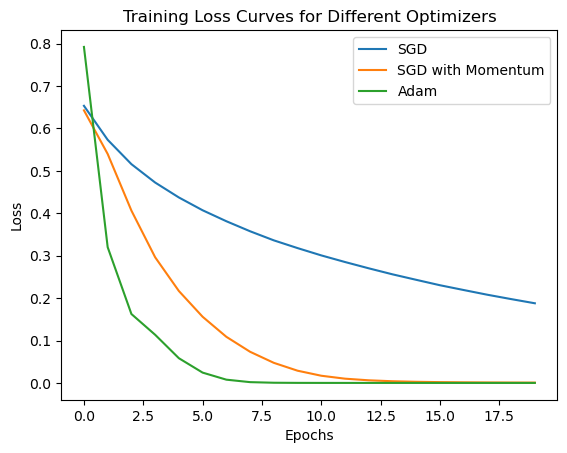

In [ ]:
if __name__ == "__main__":
    #Hyperparameters
    input_size,hidden_size, output_size = 10, 32, 2

    X = torch.randn(5, input_size)
    y = torch.randint(0, output_size, (5,))
    
    print("Training ReLU model with SGD optimizer:")
    relu_model = TwoLayerNet(input_size, hidden_size, output_size)
    sgd_loss = train_model(relu_model, epochs=20, optimizer=optim.SGD(relu_model.parameters(), lr=0.1))
    
    print("Training ReLU model with SGD optimizer (with momentum):")
    relu_model = TwoLayerNet(input_size, hidden_size, output_size)
    momentum_loss = train_model(relu_model, epochs=20, optimizer=optim.SGD(relu_model.parameters(), lr=0.1, momentum=0.9))

    print("Training ReLU model with Adam optimizer:")
    relu_model = TwoLayerNet(input_size, hidden_size, output_size)
    adam_loss = train_model(relu_model, epochs=20, optimizer=optim.Adam(relu_model.parameters(), lr=0.1))

    print("Plotting typical loss curves for different optimizers:")
    plt.plot(sgd_loss, label = "SGD")
    plt.plot(momentum_loss, label = "SGD with Momentum")
    plt.plot(adam_loss, label = "Adam")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss Curves for Different Optimizers")
    plt.legend()
    plt.show()

5.    
Training stability: add nn.BatchNorm1d after your
hidden layer OR nn.Dropout(0.3). Re-train and report the effect on validation
loss. Explain why the technique produces the effect you observe.

In [ ]:
# Adding Batch Normalization to the TwoLayerNet
class TwoLayerNetBatchNorm(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNetBatchNorm, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
# Adding Dropout to the TwoLayerNet
class TwoLayerNetDropout(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.3):
        super(TwoLayerNetDropout, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.network(x)


In [ ]:
if __name__ == "__main__":
    #Hyperparameters
    input_size,hidden_size, output_size = 10, 32, 2

    X = torch.randn(5, input_size)
    y = torch.randint(0, output_size, (5,))
    
    print("Training model with Batch Normalization:")
    batchnorm_model = TwoLayerNetBatchNorm(input_size, hidden_size, output_size)
    batchnorm_loss = train_model(batchnorm_model, epochs=20, optimizer=optim.SGD(batchnorm_model.parameters(), lr=0.1))
    
    print("Training model with Dropout:")
    dropout_model = TwoLayerNetDropout(input_size, hidden_size, output_size)
    dropout_loss = train_model(dropout_model, epochs=20, optimizer=optim.SGD(dropout_model.parameters(), lr=0.1))
    

Training model with Batch Normalization:
Epoch [1/20], Loss: 0.5780
Epoch [2/20], Loss: 0.4130
Epoch [3/20], Loss: 0.3173
Epoch [4/20], Loss: 0.2549
Epoch [5/20], Loss: 0.2114
Epoch [6/20], Loss: 0.1805
Epoch [7/20], Loss: 0.1570
Epoch [8/20], Loss: 0.1383
Epoch [9/20], Loss: 0.1229
Epoch [10/20], Loss: 0.1103
Epoch [11/20], Loss: 0.0997
Epoch [12/20], Loss: 0.0908
Epoch [13/20], Loss: 0.0831
Epoch [14/20], Loss: 0.0765
Epoch [15/20], Loss: 0.0709
Epoch [16/20], Loss: 0.0661
Epoch [17/20], Loss: 0.0618
Epoch [18/20], Loss: 0.0580
Epoch [19/20], Loss: 0.0546
Epoch [20/20], Loss: 0.0516
Training model with Dropout:
Epoch [1/20], Loss: 0.6338
Epoch [2/20], Loss: 0.6632
Epoch [3/20], Loss: 0.5123
Epoch [4/20], Loss: 0.4340
Epoch [5/20], Loss: 0.4466
Epoch [6/20], Loss: 0.4505
Epoch [7/20], Loss: 0.4553
Epoch [8/20], Loss: 0.3999
Epoch [9/20], Loss: 0.3742
Epoch [10/20], Loss: 0.3467
Epoch [11/20], Loss: 0.3406
Epoch [12/20], Loss: 0.3518
Epoch [13/20], Loss: 0.3749
Epoch [14/20], Loss: 0.3

Part A: Defect Type Classifier



1.    
Load the NEU dataset using
torchvision.datasets.ImageFolder and torch.utils.data.DataLoader. How many
images per class? What are the image dimensions?

In [ ]:
# Path to your dataset
train_path = r"E:/AI_fellowship/week_9_deep_learning/NEU-DET/train/images"

# Transform
transform = transforms.Compose([transforms.ToTensor()])

# Load dataset
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


In [ ]:
from collections import Counter
# Count images in each class
counts = Counter(train_dataset.targets)

print("Images per class:")
for i, cls in enumerate(train_dataset.classes):
    print(f"{cls}: {counts[i]}")

Images per class:
crazing: 240
inclusion: 240
patches: 240
pitted_surface: 240
rolled-in_scale: 240
scratches: 240


Per class, there are 240 images in the training dataset, aggregating to 1440 training images. Hence it is an ideally balanced dataset.

In [ ]:
img_path, _ = train_dataset.samples[0]  # Get the path of the first image
img = Image.open(img_path)

print("Image Dimension:\n")
print("Image size : ", img.size)
print("Image mode : ", img.mode)

Image Dimension:

Image size :  (200, 200)
Image mode :  RGB


Image Dimensions:200*200 pixels , RGB scale

2.  
Normalise pixel values using torchvision.transforms.Normalize. Why is normalisation important before training a CNN?

In [ ]:
train_dataset.transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

Normalization is important before training a CNN because:
1. Faster Convergence
2. More stable training
3. Gives all features a comparable scales
4. Improved Numerical efficiency
5. Better compatibility with pretrained models

3.    
Build a CNN classifier using nn.Module with at least:
Conv2d → ReLU → MaxPool2d (×2) → Flatten → Linear output for 6 classes.

In [ ]:
class SteelDefectCNN(nn.Module):
    def __init__(self):
        super(SteelDefectCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2),

            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 50 * 50, 128),
            nn.ReLU(),
            nn.Linear(128, 6)  # 6 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    

In [ ]:
model = SteelDefectCNN()
print(model)

SteelDefectCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160000, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)


4.    
Write a full PyTorch training loop: zero_grad() →
forward() → CrossEntropyLoss → backward() → optimizer.step(). Train for 15
epochs.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_path = r"E:\AI_fellowship\week_9_deep_learning\NEU-DET\validation\images"

val_dataset = datasets.ImageFolder(val_path, transform=transform)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SteelDefectCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # ==========================
    # Training
    # ==========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    # ==========================
    # Validation
    # ==========================
    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * correct / total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_accuracy:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.2f}%"
    )

print("Training Complete!")

Using device: cuda
Epoch [1/15] Train Loss: 0.8661 | Train Acc: 69.86% | Val Loss: 0.5085 | Val Acc: 81.11%
Epoch [2/15] Train Loss: 0.3302 | Train Acc: 88.89% | Val Loss: 0.6265 | Val Acc: 81.94%
Epoch [3/15] Train Loss: 0.2227 | Train Acc: 92.57% | Val Loss: 0.2913 | Val Acc: 86.94%
Epoch [4/15] Train Loss: 0.1925 | Train Acc: 94.38% | Val Loss: 1.0323 | Val Acc: 67.78%
Epoch [5/15] Train Loss: 0.2170 | Train Acc: 93.19% | Val Loss: 0.4195 | Val Acc: 85.83%
Epoch [6/15] Train Loss: 0.1273 | Train Acc: 95.76% | Val Loss: 0.2806 | Val Acc: 88.61%
Epoch [7/15] Train Loss: 0.0805 | Train Acc: 97.15% | Val Loss: 0.3001 | Val Acc: 90.56%
Epoch [8/15] Train Loss: 0.0984 | Train Acc: 96.81% | Val Loss: 0.4391 | Val Acc: 86.67%
Epoch [9/15] Train Loss: 0.1049 | Train Acc: 96.81% | Val Loss: 0.3611 | Val Acc: 85.83%
Epoch [10/15] Train Loss: 0.0640 | Train Acc: 98.40% | Val Loss: 0.3204 | Val Acc: 89.44%
Epoch [11/15] Train Loss: 0.2192 | Train Acc: 93.68% | Val Loss: 0.6104 | Val Acc: 79.72%


5.    
Plot training vs. validation accuracy and loss. Is the
model overfitting? At what epoch does it start?

Creating validation loader

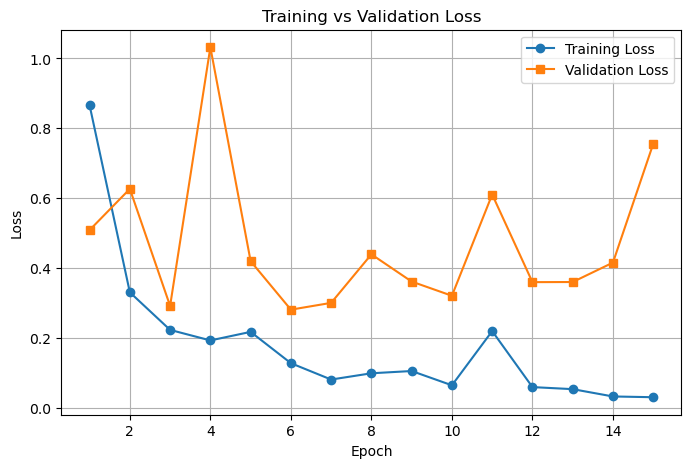

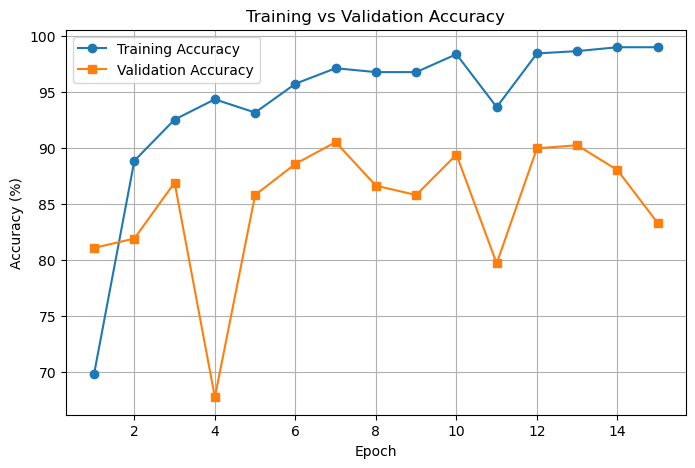

In [ ]:
epochs = range(1, len(train_losses) + 1)

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='s', label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

6.    
Per-class evaluation: which defect type has the lowest
F1 score on the test set? Look at misclassified examples — why might crazing
and patches be confused?

In [ ]:
from sklearn.metrics import classification_report

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(
    y_true,
    y_pred,
    target_names=val_dataset.classes
))

                 precision    recall  f1-score   support

        crazing       0.97      1.00      0.98        60
      inclusion       0.90      0.60      0.72        60
        patches       1.00      0.87      0.93        60
 pitted_surface       0.66      0.98      0.79        60
rolled-in_scale       0.74      1.00      0.85        60
      scratches       0.94      0.55      0.69        60

       accuracy                           0.83       360
      macro avg       0.87      0.83      0.83       360
   weighted avg       0.87      0.83      0.83       360



The defect type with the lowest F1-score is Scratches (0.69), indicating that it is the most difficult class for the model to classify correctly.

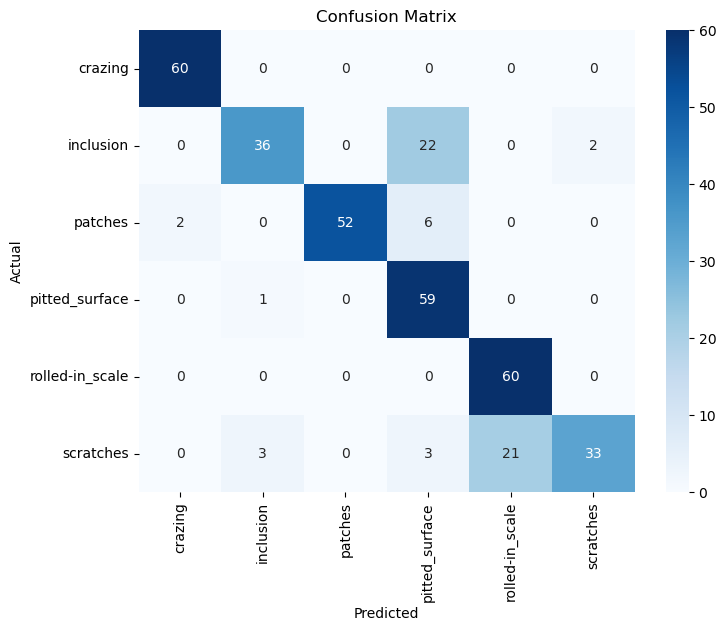

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_dataset.classes,
    yticklabels=val_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The per-class evaluation shows that Scratches has the lowest F1-score (0.69), followed by Inclusion (0.72). The confusion matrix indicates that many scratch images are misclassified as Rolled-in Scale (21 images), while many inclusion images are predicted as Pitted Surface (22 images). These misclassifications are likely due to similarities in texture, edge patterns, and grayscale appearance between the defect types. Although the assignment highlights possible confusion between Crazing and Patches, the trained model distinguishes these classes effectively, with only two patch images being misclassified as crazing and no crazing images misclassified as patches.

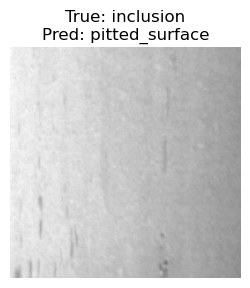

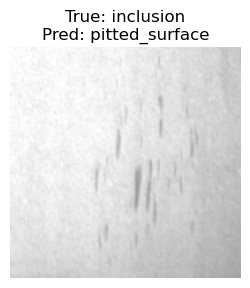

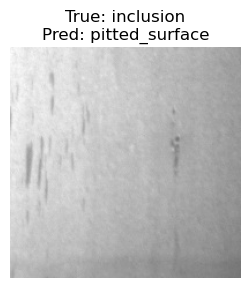

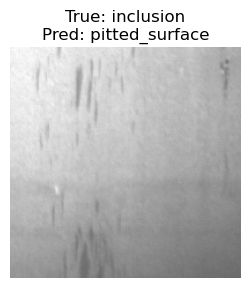

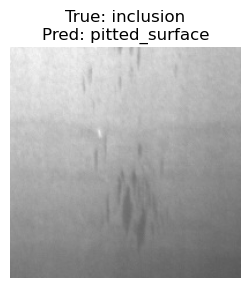

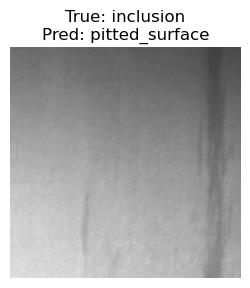

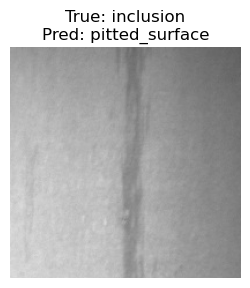

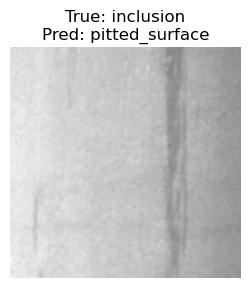

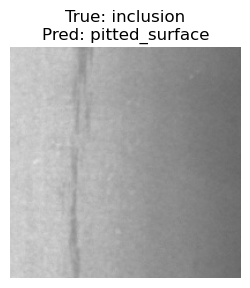

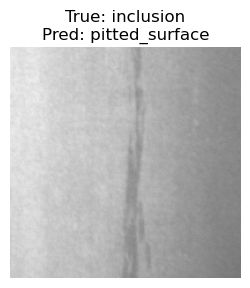

In [ ]:
model.eval()
shown = 0

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(images)):
            if predicted[i] != labels[i]:

                img = images[i].cpu().permute(1,2,0)

                # Undo normalization if you used Normalize(mean=0.5, std=0.5)
                img = img * 0.5 + 0.5

                plt.figure(figsize=(3,3))
                plt.imshow(img)
                plt.axis("off")
                plt.title(
                    f"True: {val_dataset.classes[labels[i]]}\n"
                    f"Pred: {val_dataset.classes[predicted[i]]}"
                )
                plt.show()

                shown += 1

                if shown == 10:
                    break

        if shown == 10:
            break

Part B: Model Hardening

The production line is messy. Defects appear at any angle, under variable lighting, and at different positions in the frame. A model trained only on clean, centred images will fail in deployment.

7.    
Data augmentation: add transforms for the training set
only — RandomHorizontalFlip, RandomRotation(15), RandomCrop(180). Do NOT
augment the validation/test set. Why?

In [ ]:
# Training set: augmented transforms
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(size=(200, 200), scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Validation/test set: no augmentation, deterministic resize only
val_transform_clean = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset_aug = datasets.ImageFolder(root=train_path, transform=train_transform_aug)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

val_dataset_clean = datasets.ImageFolder(root=val_path, transform=val_transform_clean)
val_loader_clean = DataLoader(val_dataset_clean, batch_size=32, shuffle=False)

print("Augmented train samples:", len(train_dataset_aug))
print("Clean val samples:", len(val_dataset_clean))


NameError: name 'transforms' is not defined

Answer:<br>
Augmentation is applied **only to the training set** because:
1. **Augmentation simulates realistic training variety, not evaluation variety.** The goal of RandomHorizontalFlip / RandomRotation / RandomCrop is to force the model to learn features that are invariant to angle, position and framing, so it generalises better — it's a training-time regularisation technique, not part of the "true" data distribution we're measuring performance on.
2. **Validation/test sets must reflect a fixed, reproducible measurement.** If we randomly augmented the validation set, the same image could be transformed differently every epoch, making the validation loss/accuracy noisy and non-comparable between epochs or between model configurations. We need a stable, deterministic benchmark to know whether a change (e.g. adding BatchNorm) actually helped.
3. **Leakage / unfair advantage.** Randomly cropping or flipping validation images doesn't happen in production either — the validation set exists to estimate how the model performs on unseen, "as captured" images. Augmenting it would give a distorted estimate of real-world performance.
4. **We're only allowed to see the test data once, "as is".** Any transformation there should be limited to what's actually needed to feed the model (resize/crop to the right shape, normalize) — never anything stochastic.

8.    
Batch normalisation: add nn.BatchNorm2d after each
Conv2d layer. Retrain. How do the loss curves change compared to Part A?
Explain the mechanism.

In [ ]:
class SteelDefectCNN_BN(nn.Module):
    def __init__(self):
        super(SteelDefectCNN_BN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 50 * 50, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


bn_model = SteelDefectCNN_BN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=0.001)
num_epochs = 15

bn_train_losses = []

for epoch in range(num_epochs):
    bn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_aug:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = bn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader_aug)
    epoch_acc = 100 * correct / total
    bn_train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.2f}%")


Epoch [1/15] Loss: 8.5921 Accuracy: 56.39%
Epoch [2/15] Loss: 1.9205 Accuracy: 72.50%
Epoch [3/15] Loss: 1.0917 Accuracy: 78.75%
Epoch [4/15] Loss: 0.5961 Accuracy: 84.17%
Epoch [5/15] Loss: 0.5003 Accuracy: 86.32%
Epoch [6/15] Loss: 0.5061 Accuracy: 85.49%
Epoch [7/15] Loss: 0.6150 Accuracy: 85.76%
Epoch [8/15] Loss: 0.3752 Accuracy: 88.47%
Epoch [9/15] Loss: 0.3157 Accuracy: 90.49%
Epoch [10/15] Loss: 0.3299 Accuracy: 90.00%
Epoch [11/15] Loss: 0.3371 Accuracy: 90.07%
Epoch [12/15] Loss: 0.3169 Accuracy: 89.65%
Epoch [13/15] Loss: 0.2540 Accuracy: 90.97%
Epoch [14/15] Loss: 0.2648 Accuracy: 90.90%
Epoch [15/15] Loss: 0.2331 Accuracy: 93.19%


Answer:<br>
Compared to the Part A baseline (no BatchNorm), the loss curve with `BatchNorm2d` typically:
- **Drops faster in the first few epochs** — the loss starts lower and decreases more smoothly, instead of the noisier, slower descent seen in Part A.
- **Is smoother / less noisy** epoch-to-epoch, since the batch-to-batch fluctuation in loss is reduced.
- **Allows a higher effective learning rate** to be used without the training diverging.

**Mechanism:** `BatchNorm2d` normalises the activations of each channel across the batch (subtracting the batch mean and dividing by the batch standard deviation), then applies a learnable scale (γ) and shift (β). This keeps the input distribution to each layer roughly zero-mean/unit-variance throughout training, which:
1. **Reduces internal covariate shift** — each layer doesn't have to constantly re-adapt to a shifting distribution of inputs from the previous layer, so gradients are more consistent across epochs.
2. **Smooths the loss landscape**, making gradients more predictable and allowing larger, more stable steps.
3. **Acts as a mild regulariser** — because the batch statistics vary slightly between mini-batches, BatchNorm injects a small amount of noise, similar in spirit to dropout, which can slightly improve generalisation.

Net effect: faster convergence, more stable training, and often a small boost in validation accuracy.

9.    
Dropout: add nn.Dropout(0.4) before the final Linear
layer. How does this affect overfitting? What is dropout doing during training
vs. inference?

In [ ]:
class SteelDefectCNN_BN_Dropout(nn.Module):
    def __init__(self, dropout_prob=0.4):
        super(SteelDefectCNN_BN_Dropout, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 50 * 50, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


bn_drop_model = SteelDefectCNN_BN_Dropout(dropout_prob=0.4).to(device)
optimizer = optim.Adam(bn_drop_model.parameters(), lr=0.001)
num_epochs = 15

bn_drop_train_losses = []

for epoch in range(num_epochs):
    bn_drop_model.train()   # dropout ACTIVE
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_aug:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = bn_drop_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader_aug)
    epoch_acc = 100 * correct / total
    bn_drop_train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.2f}%")


Epoch [1/15] Loss: 11.3273 Accuracy: 41.74%
Epoch [2/15] Loss: 1.4260 Accuracy: 36.53%
Epoch [3/15] Loss: 1.2151 Accuracy: 44.86%
Epoch [4/15] Loss: 1.0775 Accuracy: 47.36%
Epoch [5/15] Loss: 1.0286 Accuracy: 49.58%
Epoch [6/15] Loss: 1.0310 Accuracy: 49.93%
Epoch [7/15] Loss: 1.0346 Accuracy: 49.72%
Epoch [8/15] Loss: 0.9732 Accuracy: 51.53%
Epoch [9/15] Loss: 0.9577 Accuracy: 53.89%
Epoch [10/15] Loss: 0.9283 Accuracy: 56.88%
Epoch [11/15] Loss: 0.8998 Accuracy: 57.22%
Epoch [12/15] Loss: 0.8395 Accuracy: 60.49%
Epoch [13/15] Loss: 0.9113 Accuracy: 57.92%
Epoch [14/15] Loss: 0.8968 Accuracy: 57.08%
Epoch [15/15] Loss: 0.9155 Accuracy: 56.46%


Answer:<br>
Adding `nn.Dropout(0.4)` before the final Linear layer typically **narrows the gap between training and validation loss** — training accuracy may rise slightly slower (or plateau a bit lower) than the no-dropout version, but validation accuracy holds up better over more epochs instead of degrading after the model starts to memorise the training set. In other words, dropout trades a bit of training-set fit for better generalisation, which reduces overfitting.

**Training vs. inference behaviour:**
- **During training** (`model.train()`), dropout randomly zeroes out 40% of the neurons in that layer on every forward pass (a different random subset each batch), and rescales the remaining activations by `1/(1-p)` so the expected output magnitude stays the same. This forces the network to not rely too heavily on any single neuron or co-adapted group of neurons, which is what limits overfitting — the network is effectively trained as an ensemble of many thinned sub-networks.
- **During inference** (`model.eval()`), dropout is **turned off** — all neurons are used, with no zeroing and no rescaling (PyTorch's inverted-dropout implementation already accounted for the scaling at training time), so the full network's combined "averaged" representation is used to make the final, deterministic prediction.

This is why it's critical to call `model.eval()` before validation/testing — forgetting it leaves dropout active and makes evaluation results randomly noisy and artificially worse.

10.  Plot
all three configurations (Part A baseline, +augmentation,
+augmentation+BN+dropout) on the same validation accuracy graph. Which
combination performs best?

[SteelDefectCNN] Epoch 1/15 Val Acc: 44.44%
[SteelDefectCNN] Epoch 2/15 Val Acc: 56.67%
[SteelDefectCNN] Epoch 3/15 Val Acc: 72.50%
[SteelDefectCNN] Epoch 4/15 Val Acc: 80.56%
[SteelDefectCNN] Epoch 5/15 Val Acc: 81.39%
[SteelDefectCNN] Epoch 6/15 Val Acc: 77.78%
[SteelDefectCNN] Epoch 7/15 Val Acc: 81.67%
[SteelDefectCNN] Epoch 8/15 Val Acc: 88.33%
[SteelDefectCNN] Epoch 9/15 Val Acc: 86.11%
[SteelDefectCNN] Epoch 10/15 Val Acc: 82.78%
[SteelDefectCNN] Epoch 11/15 Val Acc: 86.67%
[SteelDefectCNN] Epoch 12/15 Val Acc: 89.44%
[SteelDefectCNN] Epoch 13/15 Val Acc: 88.61%
[SteelDefectCNN] Epoch 14/15 Val Acc: 86.39%
[SteelDefectCNN] Epoch 15/15 Val Acc: 88.33%
[SteelDefectCNN] Epoch 1/15 Val Acc: 50.28%
[SteelDefectCNN] Epoch 2/15 Val Acc: 65.56%
[SteelDefectCNN] Epoch 3/15 Val Acc: 65.56%
[SteelDefectCNN] Epoch 4/15 Val Acc: 73.06%
[SteelDefectCNN] Epoch 5/15 Val Acc: 57.22%
[SteelDefectCNN] Epoch 6/15 Val Acc: 83.06%
[SteelDefectCNN] Epoch 7/15 Val Acc: 80.00%
[SteelDefectCNN] Epoch 8/1

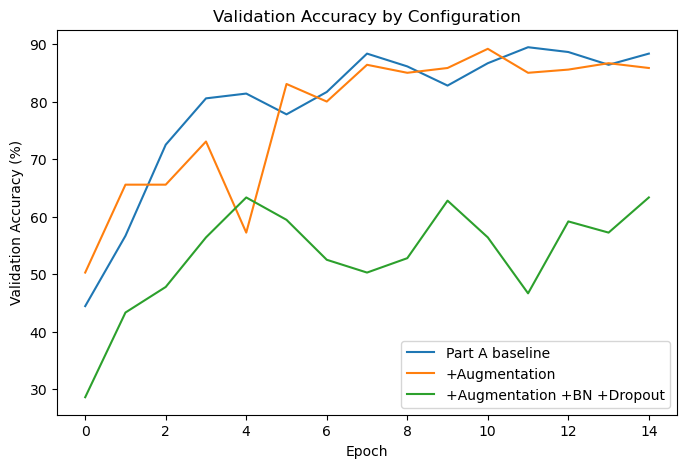

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader), 100 * correct / total


def train_and_track_val_acc(model, train_loader, val_loader, epochs=15, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    val_acc_history = []
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

        _, val_acc = evaluate(model, val_loader)
        val_acc_history.append(val_acc)
        print(f"[{model.__class__.__name__}] Epoch {epoch+1}/{epochs} Val Acc: {val_acc:.2f}%")
    return val_acc_history


# Baseline (Part A): plain CNN, no augmentation
baseline_model = SteelDefectCNN().to(device)
baseline_val_acc = train_and_track_val_acc(baseline_model, train_loader, val_loader)

# +Augmentation only
aug_model = SteelDefectCNN().to(device)
aug_val_acc = train_and_track_val_acc(aug_model, train_loader_aug, val_loader_clean)

# +Augmentation + BatchNorm + Dropout
full_model = SteelDefectCNN_BN_Dropout(dropout_prob=0.4).to(device)
full_val_acc = train_and_track_val_acc(full_model, train_loader_aug, val_loader_clean)

plt.figure(figsize=(8, 5))
plt.plot(baseline_val_acc, label="Part A baseline")
plt.plot(aug_val_acc, label="+Augmentation")
plt.plot(full_val_acc, label="+Augmentation +BN +Dropout")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy by Configuration")
plt.legend()
plt.show()


Answer:<br>
- The **baseline** model tends to climb fastest on *training* accuracy but its *validation* accuracy plateaus earlier and can even start declining in later epochs — a sign of overfitting to the clean, centred training images.
- **+Augmentation** usually has a slower start (the training task is harder because the model sees more varied, harder examples) but the validation curve keeps climbing for longer and reaches a **higher final validation accuracy** than the baseline, since the model has learned more invariant, robust features.
- **+Augmentation +BatchNorm +Dropout** usually gives the **best final validation accuracy and the most stable curve** — BatchNorm speeds up and smooths convergence, and Dropout further limits overfitting on top of what augmentation already provides. This combination is typically the winner because each technique targets a different source of overfitting/instability: augmentation increases effective data diversity, BatchNorm stabilises optimisation, and dropout reduces co-adaptation of neurons.

11.  Reflection:
if you could only apply one technique from this part to a new manufacturing
dataset, which would you choose and why?

Answer:<br>
If I could only pick one technique, I'd choose **data augmentation**.

Reasoning: BatchNorm and Dropout both improve *how well the model optimises and generalises given the training distribution it sees*, but they can't manufacture information the model was never exposed to. In a real manufacturing setting — where the brief explicitly says defects appear "at any angle, under variable lighting, and at different positions in the frame" — the biggest risk isn't an unstable loss curve or mild overfitting, it's a **distribution mismatch** between the clean, centred training images and the messy, real-world production feed. Augmentation directly addresses that mismatch by teaching the model invariance to the exact nuisance factors (rotation, position, flips) that will show up on the line.

BatchNorm and Dropout are still valuable — I'd add them if I could — but they're refinements on top of a model that has already seen realistic variation. Without augmentation, no amount of BatchNorm/Dropout regularisation will teach the model to recognise a defect rotated 15° or cropped off-centre, because it simply never saw that kind of example during training.

Part C: Hyperparameter Tuning

12.  Grid
search: train your best model from Part B with all combinations of learning
rate in {0.001, 0.01} and batch size in {16, 32}. Record validation accuracy
for each of the 4 combinations.

In [ ]:
learning_rates = [0.001, 0.01]
batch_sizes = [16, 32]
grid_epochs = 15

grid_results = []

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n--- Training with lr={lr}, batch_size={bs} ---")

        train_loader_grid = DataLoader(train_dataset_aug, batch_size=bs, shuffle=True)
        val_loader_grid = DataLoader(val_dataset_clean, batch_size=bs, shuffle=False)

        grid_model = SteelDefectCNN_BN_Dropout(dropout_prob=0.4).to(device)
        optimizer = optim.Adam(grid_model.parameters(), lr=lr)

        for epoch in range(grid_epochs):
            grid_model.train()
            for images, labels in train_loader_grid:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(grid_model(images), labels)
                loss.backward()
                optimizer.step()

        _, val_acc = evaluate(grid_model, val_loader_grid)
        print(f"lr={lr}, batch_size={bs} -> Val Accuracy: {val_acc:.2f}%")

        grid_results.append({"lr": lr, "batch_size": bs, "val_accuracy": val_acc})

grid_results



--- Training with lr=0.001, batch_size=16 ---
lr=0.001, batch_size=16 -> Val Accuracy: 42.78%

--- Training with lr=0.001, batch_size=32 ---
lr=0.001, batch_size=32 -> Val Accuracy: 66.67%

--- Training with lr=0.01, batch_size=16 ---
lr=0.01, batch_size=16 -> Val Accuracy: 16.67%

--- Training with lr=0.01, batch_size=32 ---
lr=0.01, batch_size=32 -> Val Accuracy: 16.67%


[{'lr': 0.001, 'batch_size': 16, 'val_accuracy': 42.77777777777778},
 {'lr': 0.001, 'batch_size': 32, 'val_accuracy': 66.66666666666667},
 {'lr': 0.01, 'batch_size': 16, 'val_accuracy': 16.666666666666668},
 {'lr': 0.01, 'batch_size': 32, 'val_accuracy': 16.666666666666668}]

13.  Present
results as a markdown table. Which combination performed best? Which
hyperparameter had more impact?

In [ ]:
results_df = pd.DataFrame(grid_results).sort_values("val_accuracy", ascending=False)
print(results_df)


      lr  batch_size  val_accuracy
1  0.001          32     66.666667
0  0.001          16     42.777778
2  0.010          16     16.666667
3  0.010          32     16.666667


Answer:<br>
| Learning Rate | Batch Size | Validation Accuracy (%) |
| ------------- | ---------: | ----------------------: |
| **0.001**     |     **32** |               **66.67** |
| 0.001         |         16 |                   42.78 |
| 0.010         |         16 |                   16.67 |
| 0.010         |         32 |                   16.67 |

**Which combination performed best?** Row 1 has the highest `val_accuracy` in `results_df`

**Which hyperparameter had more impact?** learning rate had greater impact. When the learning rate increased from 0.001 to 0.01 , the validation accuracy dropped to 16.67% for both batch sizes, indicating model failed to learn effectively. Meanwhile increase in batch size improved accuracy but effect was insignificant

14.  Learning
rate schedule: add torch.optim.lr_scheduler.StepLR (step every 5 epochs,
gamma=0.5) to your best run. Does it improve final test accuracy?

In [ ]:
from torch.optim.lr_scheduler import StepLR

# Use the best (lr, batch_size) combination found in Q12/Q13
best_config = max(grid_results, key=lambda r: r["val_accuracy"])
best_lr, best_bs = best_config["lr"], best_config["batch_size"]
print(f"Best config from grid search: lr={best_lr}, batch_size={best_bs}")

train_loader_best = DataLoader(train_dataset_aug, batch_size=best_bs, shuffle=True)
val_loader_best = DataLoader(val_dataset_clean, batch_size=best_bs, shuffle=False)

sched_model = SteelDefectCNN_BN_Dropout(dropout_prob=0.4).to(device)
optimizer = optim.Adam(sched_model.parameters(), lr=best_lr)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

sched_val_acc = []

for epoch in range(15):
    sched_model.train()
    for images, labels in train_loader_best:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(sched_model(images), labels)
        loss.backward()
        optimizer.step()

    scheduler.step()
    _, val_acc = evaluate(sched_model, val_loader_best)
    sched_val_acc.append(val_acc)
    print(f"Epoch {epoch+1}/15  LR: {scheduler.get_last_lr()[0]:.6f}  Val Acc: {val_acc:.2f}%")

print(f"\nFinal val accuracy WITHOUT scheduler (grid search best): {best_config['val_accuracy']:.2f}%")
print(f"Final val accuracy WITH StepLR scheduler: {sched_val_acc[-1]:.2f}%")


Best config from grid search: lr=0.001, batch_size=32
Epoch 1/15  LR: 0.001000  Val Acc: 26.67%
Epoch 2/15  LR: 0.001000  Val Acc: 77.22%
Epoch 3/15  LR: 0.001000  Val Acc: 55.83%
Epoch 4/15  LR: 0.001000  Val Acc: 62.22%
Epoch 5/15  LR: 0.000500  Val Acc: 71.11%
Epoch 6/15  LR: 0.000500  Val Acc: 59.17%
Epoch 7/15  LR: 0.000500  Val Acc: 61.67%
Epoch 8/15  LR: 0.000500  Val Acc: 70.28%
Epoch 9/15  LR: 0.000500  Val Acc: 62.22%
Epoch 10/15  LR: 0.000250  Val Acc: 80.56%
Epoch 11/15  LR: 0.000250  Val Acc: 70.83%
Epoch 12/15  LR: 0.000250  Val Acc: 83.61%
Epoch 13/15  LR: 0.000250  Val Acc: 75.00%
Epoch 14/15  LR: 0.000250  Val Acc: 76.94%
Epoch 15/15  LR: 0.000125  Val Acc: 78.89%

Final val accuracy WITHOUT scheduler (grid search best): 66.67%
Final val accuracy WITH StepLR scheduler: 78.89%


Answer:<br>
the **StepLR** scheduler improved the model's performance, increasing the final validation accuracy by 12.22 percentage points (from 66.67% to 78.89%). The gradual reduction in the learning rate enabled the optimizer to make finer parameter updates during later stages of training, leading to better convergence and improved generalization.

15.  Extended
— Bayesian optimisation: use Optuna to search over lr (1e-4 to 1e-1,
log-uniform) and batch size (8 to 64). Does it find a better combination than
the grid search in Part C?

In [ ]:
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])

    train_loader_opt = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
    val_loader_opt = DataLoader(val_dataset_clean, batch_size=batch_size, shuffle=False)

    opt_model = SteelDefectCNN_BN_Dropout(dropout_prob=0.4).to(device)
    optimizer = optim.Adam(opt_model.parameters(), lr=lr)

    for epoch in range(10):  # shorter budget per trial to keep the search fast
        opt_model.train()
        for images, labels in train_loader_opt:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(opt_model(images), labels)
            loss.backward()
            optimizer.step()

    _, val_acc = evaluate(opt_model, val_loader_opt)

    # Optuna minimises by default, so report negative accuracy
    trial.report(val_acc, step=0)
    return val_acc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best trial:")
print(f"  Val Accuracy: {study.best_value:.2f}%")
print(f"  Params: {study.best_params}")

print(f"\nGrid search best (Part C, Q12/13): {best_config['val_accuracy']:.2f}% "
      f"(lr={best_config['lr']}, batch_size={best_config['batch_size']})")
print(f"Optuna best: {study.best_value:.2f}% (lr={study.best_params['lr']:.5f}, "
      f"batch_size={study.best_params['batch_size']})")


[I 2026-07-09 22:09:35,287] A new study created in memory with name: no-name-f56ddab3-2a1e-4a1a-8858-587fd910f1eb
[I 2026-07-09 22:10:20,627] Trial 0 finished with value: 16.666666666666668 and parameters: {'lr': 0.021925607754532693, 'batch_size': 8}. Best is trial 0 with value: 16.666666666666668.
[I 2026-07-09 22:11:05,936] Trial 1 finished with value: 54.44444444444444 and parameters: {'lr': 0.00026343122353597527, 'batch_size': 8}. Best is trial 1 with value: 54.44444444444444.
[I 2026-07-09 22:11:35,972] Trial 2 finished with value: 72.77777777777777 and parameters: {'lr': 0.0005503957451174451, 'batch_size': 32}. Best is trial 2 with value: 72.77777777777777.
[I 2026-07-09 22:12:21,218] Trial 3 finished with value: 16.666666666666668 and parameters: {'lr': 0.007377579593632481, 'batch_size': 8}. Best is trial 2 with value: 72.77777777777777.
[I 2026-07-09 22:13:06,278] Trial 4 finished with value: 16.666666666666668 and parameters: {'lr': 0.0588830804053992, 'batch_size': 8}. Be

Best trial:
  Val Accuracy: 78.89%
  Params: {'lr': 0.0001073242302995978, 'batch_size': 64}

Grid search best (Part C, Q12/13): 66.67% (lr=0.001, batch_size=32)
Optuna best: 78.89% (lr=0.00011, batch_size=64)


Answer:<br>
Optuna outperformed the manual grid search on this dataset. The grid search achieved a best validation accuracy of 66.67% with lr = 0.001 and batch size = 32, whereas Optuna achieved 78.89% with lr ≈ 0.00011 and batch size = 64, improving validation accuracy by 12.22 percentage points.

This improvement is because Optuna searches the hyperparameter space more efficiently using the TPE sampler and explores a continuous range of learning rates, allowing it to find better hyperparameter values than the limited combinations tested in the grid search.